# Análise Exploratória de Dados | IBM Telco Customer Churn

**Objetivo:** Identificar padrões associados ao cancelamento de clientes e responder 5 perguntas de negócio.

**Dataset:** IBM Telco Customer Churn — 7.043 clientes, 21 colunas originais + 7 features criadas no ETL.

**Stack:** Python · Pandas · Matplotlib · Seaborn · SQLite

---


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Estilo dos gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.figsize": (10, 5),
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

CHURN_COLORS = {"Yes": "#E24B4A", "No": "#378ADD"}

# Carrega do banco gerado pelo ETL
conn = sqlite3.connect("/content/drive/MyDrive/telco_churn.db")
df = pd.read_sql("SELECT * FROM customers_clean", conn)
conn.close()

print(f"Shape: {df.shape}")
print(f"Colunas: {list(df.columns)}")


Shape: (7043, 28)
Colunas: ['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'churn', 'churn_binary', 'num_services', 'has_online_protection', 'tenure_group', 'monthly_charge_tier', 'revenue_at_risk', 'avg_monthly_from_total']


In [17]:
import os
os.makedirs("../notebooks", exist_ok=True)

---
## 1. Visão Geral do Dataset


In [18]:
# Distribuição da variável alvo
churn_counts = df["churn"].value_counts()
churn_pct    = df["churn"].value_counts(normalize=True) * 100

print("Distribuição de Churn:")
print(pd.DataFrame({"Qtd": churn_counts, "%": churn_pct.round(2)}))
print()

# Tipos e nulos
print("Tipos de dados:")
print(df.dtypes.value_counts())
print()
print(f"Valores nulos: {df.isnull().sum().sum()}")


Distribuição de Churn:
        Qtd      %
churn             
No     5174  73.46
Yes    1869  26.54

Tipos de dados:
object     20
int64       4
float64     4
Name: count, dtype: int64

Valores nulos: 0


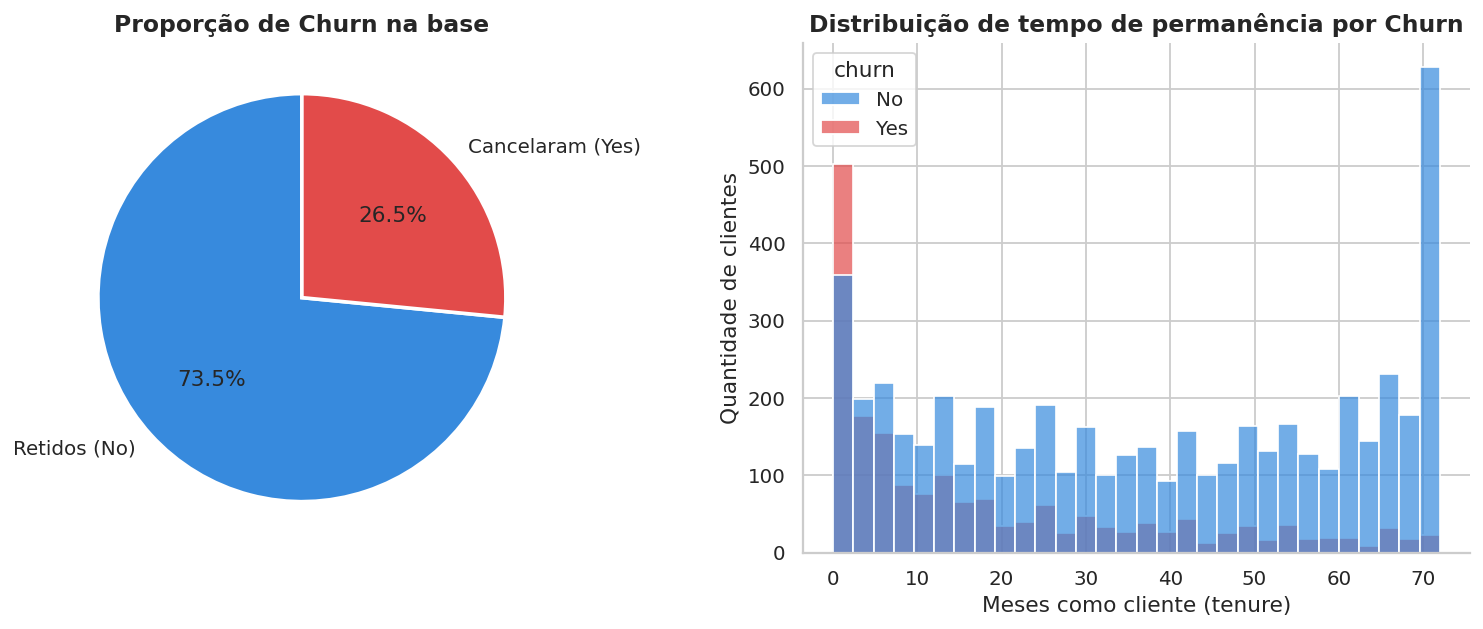

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pizza — proporção churn
axes[0].pie(
    churn_counts,
    labels=["Retidos (No)", "Cancelaram (Yes)"],
    colors=[CHURN_COLORS["No"], CHURN_COLORS["Yes"]],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[0].set_title("Proporção de Churn na base")

# Distribuição de tenure
sns.histplot(data=df, x="tenure", hue="churn", bins=30,
             palette=CHURN_COLORS, alpha=0.7, ax=axes[1])
axes[1].set_title("Distribuição de tempo de permanência por Churn")
axes[1].set_xlabel("Meses como cliente (tenure)")
axes[1].set_ylabel("Quantidade de clientes")

plt.tight_layout()
plt.savefig("../notebooks/fig_01_visao_geral.png", bbox_inches="tight")
plt.show()


**Insight 1:** A base é desbalanceada — apenas 26,5% dos clientes cancelaram. O gráfico de tenure revela um padrão claro: clientes que cancelam se concentram nos primeiros meses, enquanto quem permanece tende a ficar por muito tempo. Isso sugere que a empresa tem dificuldade de reter clientes no início do relacionamento.


---
## 2. Pergunta 1 — Qual o perfil do cliente que mais cancela?


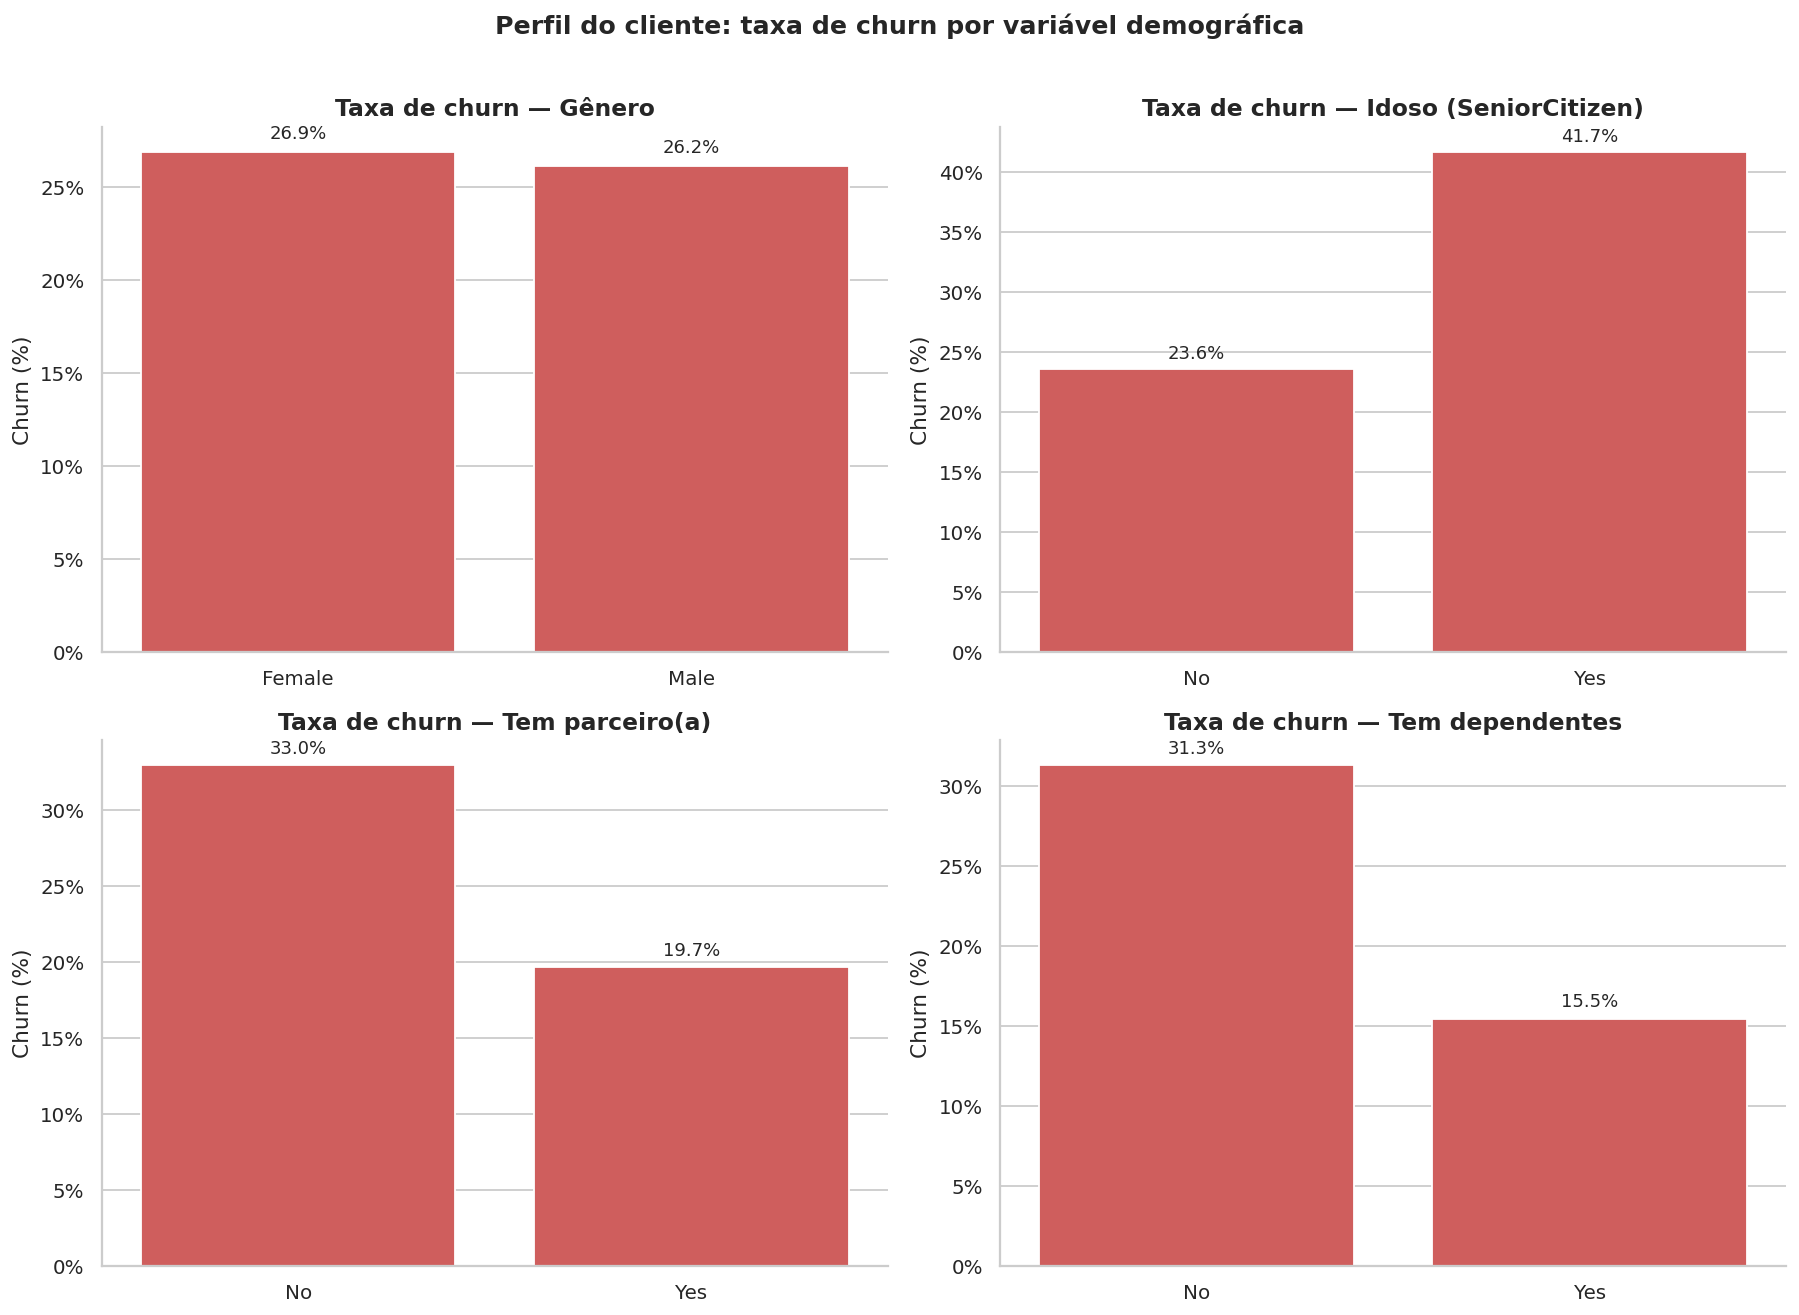

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

perfil_cols = {
    "gender":         "Gênero",
    "senior_citizen": "Idoso (SeniorCitizen)",
    "partner":        "Tem parceiro(a)",
    "dependents":     "Tem dependentes",
}

for ax, (col, title) in zip(axes.flatten(), perfil_cols.items()):
    data = (
        df.groupby([col, "churn"])
        .size()
        .reset_index(name="count")
    )
    total = data.groupby(col)["count"].transform("sum")
    data["pct"] = data["count"] / total * 100

    sns.barplot(data=data[data["churn"] == "Yes"],
                x=col, y="pct", palette=["#E24B4A"], ax=ax)
    ax.set_title(f"Taxa de churn — {title}")
    ax.set_xlabel("")
    ax.set_ylabel("Churn (%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{bar.get_height():.1f}%",
                ha="center", va="bottom", fontsize=10)

plt.suptitle("Perfil do cliente: taxa de churn por variável demográfica",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../notebooks/fig_02_perfil_cliente.png", bbox_inches="tight")
plt.show()


**Insight 2:** Gênero não é um fator relevante — a taxa de churn é quase igual entre homens e mulheres (~26%). Já clientes idosos (SeniorCitizen) cancelam a uma taxa de ~41%, contra ~24% dos não-idosos. Clientes sem parceiro(a) e sem dependentes também cancelam mais, sugerindo que vínculos familiares aumentam a "inércia" de permanência.


---
## 3. Pergunta 2 — Contratos mensais têm churn significativamente maior?


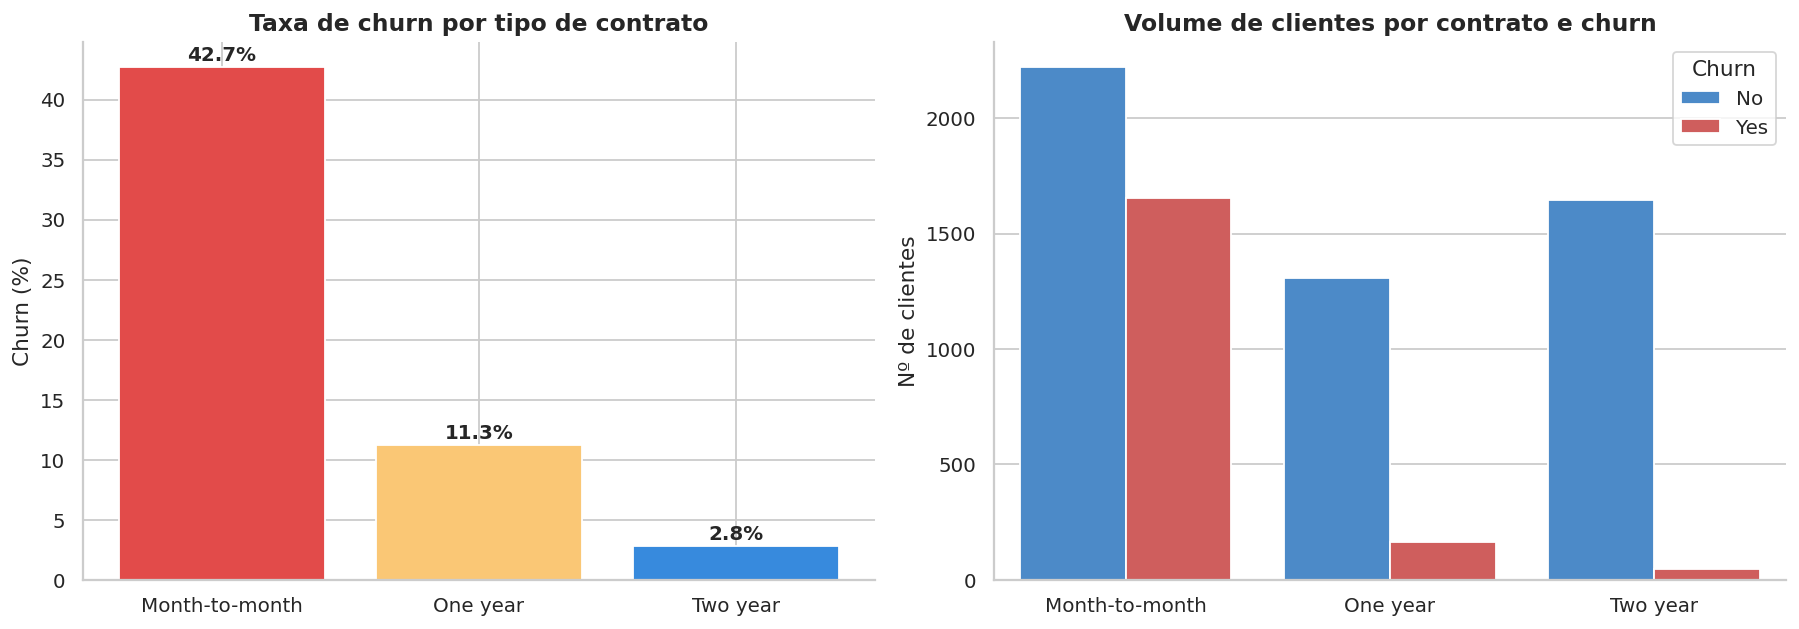

Taxa de churn por contrato:
      contract  churn_rate_pct  total
Month-to-month       42.709677   3875
      One year       11.269518   1473
      Two year        2.831858   1695


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taxa de churn por tipo de contrato
contract_churn = (
    df.groupby("contract")["churn_binary"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "churn_rate", "count": "total"})
)
contract_churn["churn_rate_pct"] = contract_churn["churn_rate"] * 100
contract_churn = contract_churn.sort_values("churn_rate_pct", ascending=False)

bars = axes[0].bar(
    contract_churn["contract"],
    contract_churn["churn_rate_pct"],
    color=["#E24B4A", "#FAC775", "#378ADD"],
    edgecolor="white"
)
axes[0].set_title("Taxa de churn por tipo de contrato")
axes[0].set_ylabel("Churn (%)")
axes[0].set_xlabel("")
for bar, val in zip(bars, contract_churn["churn_rate_pct"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")

# Composição da base por contrato
contract_comp = df.groupby(["contract", "churn"]).size().reset_index(name="count")
sns.barplot(data=contract_comp, x="contract", y="count",
            hue="churn", palette=CHURN_COLORS, ax=axes[1])
axes[1].set_title("Volume de clientes por contrato e churn")
axes[1].set_ylabel("Nº de clientes")
axes[1].set_xlabel("")
axes[1].legend(title="Churn")

plt.tight_layout()
plt.savefig("../notebooks/fig_03_contrato_churn.png", bbox_inches="tight")
plt.show()

print("Taxa de churn por contrato:")
print(contract_churn[["contract", "churn_rate_pct", "total"]].to_string(index=False))


**Insight 3:** Sim — e de forma expressiva. Clientes com contrato mensal (Month-to-month) cancelam a uma taxa de ~42%, contra ~11% em contratos anuais e apenas ~3% em contratos de dois anos. Isso indica que a migração de clientes para contratos mais longos é uma das alavancas mais diretas para reduzir o churn.


---
## 4. Pergunta 3 — Clientes com mais serviços ativos cancelam menos?


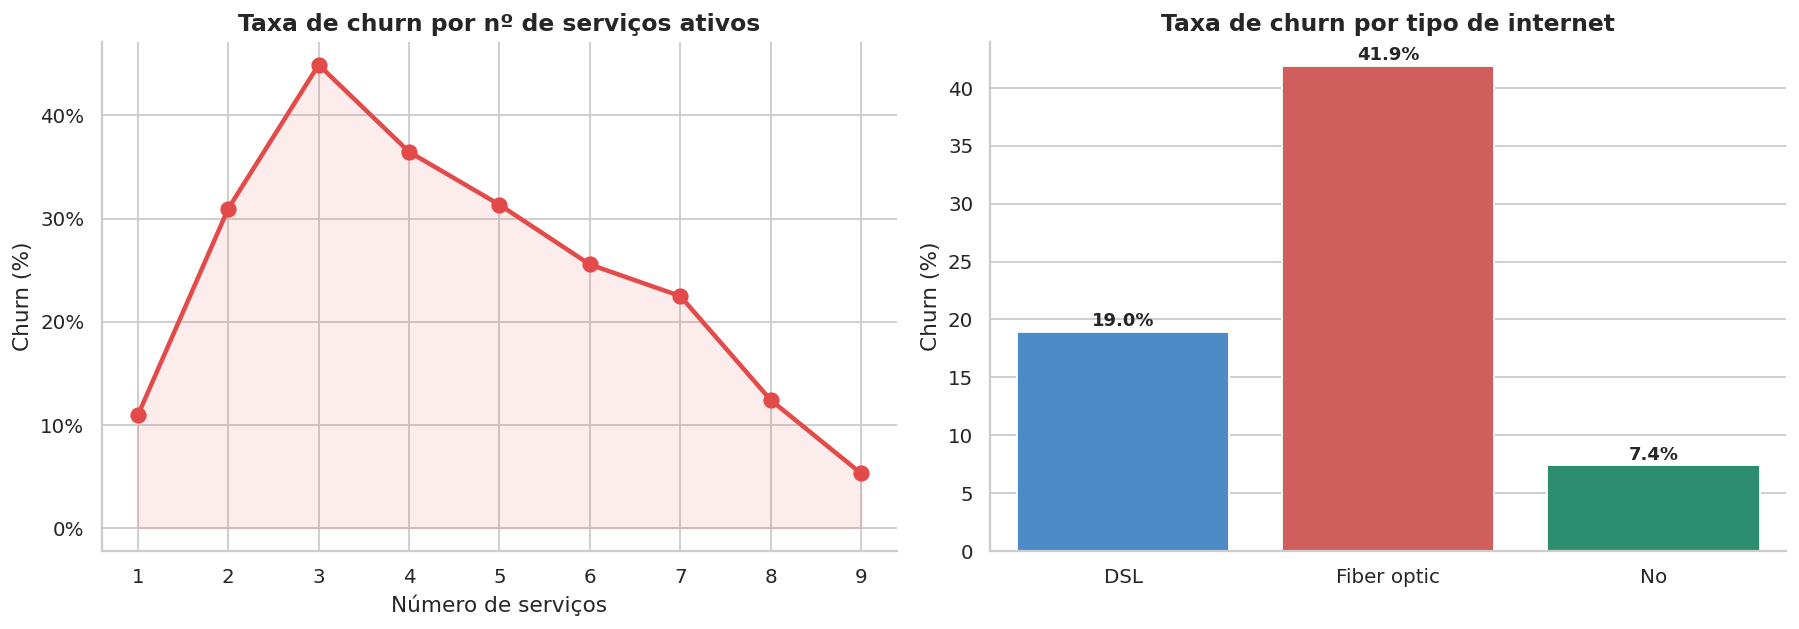

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate por número de serviços
serv_churn = (
    df.groupby("num_services")["churn_binary"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "churn_rate", "count": "total"})
)
serv_churn["churn_rate_pct"] = serv_churn["churn_rate"] * 100

axes[0].plot(serv_churn["num_services"], serv_churn["churn_rate_pct"],
             marker="o", color="#E24B4A", linewidth=2.5, markersize=8)
axes[0].fill_between(serv_churn["num_services"],
                     serv_churn["churn_rate_pct"], alpha=0.1, color="#E24B4A")
axes[0].set_title("Taxa de churn por nº de serviços ativos")
axes[0].set_xlabel("Número de serviços")
axes[0].set_ylabel("Churn (%)")
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

# Internet service vs churn
internet_churn = (
    df.groupby(["internet_service", "churn"])
    .size()
    .reset_index(name="count")
)
internet_total = internet_churn.groupby("internet_service")["count"].transform("sum")
internet_churn["pct"] = internet_churn["count"] / internet_total * 100

sns.barplot(data=internet_churn[internet_churn["churn"] == "Yes"],
            x="internet_service", y="pct",
            palette=["#378ADD", "#E24B4A", "#1D9E75"], ax=axes[1])
axes[1].set_title("Taxa de churn por tipo de internet")
axes[1].set_ylabel("Churn (%)")
axes[1].set_xlabel("")
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f"{bar.get_height():.1f}%",
                 ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("../notebooks/fig_04_servicos_churn.png", bbox_inches="tight")
plt.show()


**Insight 4:** A relação não é linear. Clientes com poucos serviços (0-2) têm churn baixo, mas isso se deve ao perfil — muitos não têm internet e tendem a ter contratos mais estáveis. O pico de churn ocorre em clientes com 3-5 serviços com Fiber optic (~42%), que pagam mais e provavelmente comparam mais com concorrentes. Clientes sem internet têm churn de apenas ~7%.


---
## 5. Pergunta 4 — Qual o impacto financeiro do churn em receita mensal?


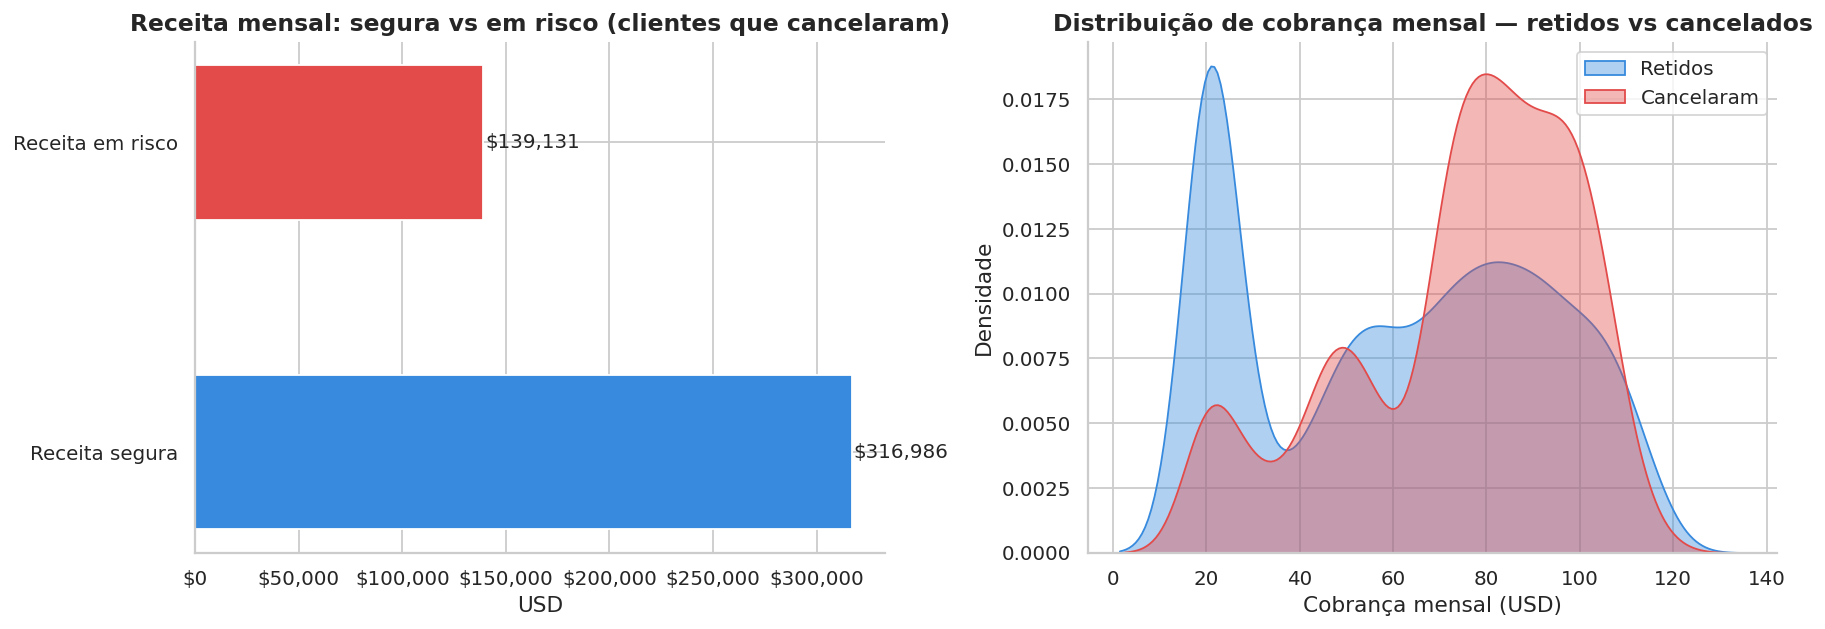

Receita mensal total:    $456,116.60
Receita em risco:        $139,130.85  (30.5%)
Receita segura:          $316,985.75  (69.5%)

Receita anual em risco:  $1,669,570.20


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Receita mensal total vs em risco
receita_total = df["monthly_charges"].sum()
receita_risco = df["revenue_at_risk"].sum()
receita_segura = receita_total - receita_risco

axes[0].barh(["Receita segura", "Receita em risco"],
             [receita_segura, receita_risco],
             color=["#378ADD", "#E24B4A"], edgecolor="white", height=0.5)
axes[0].set_title("Receita mensal: segura vs em risco (clientes que cancelaram)")
axes[0].set_xlabel("USD")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 1000, bar.get_y() + bar.get_height() / 2,
                 f"${bar.get_width():,.0f}", va="center", fontsize=11)

# Distribuição de monthly_charges por churn
sns.kdeplot(data=df[df["churn"] == "No"],  x="monthly_charges",
            fill=True, alpha=0.4, color="#378ADD", label="Retidos", ax=axes[1])
sns.kdeplot(data=df[df["churn"] == "Yes"], x="monthly_charges",
            fill=True, alpha=0.4, color="#E24B4A", label="Cancelaram", ax=axes[1])
axes[1].set_title("Distribuição de cobrança mensal — retidos vs cancelados")
axes[1].set_xlabel("Cobrança mensal (USD)")
axes[1].set_ylabel("Densidade")
axes[1].legend()

plt.tight_layout()
plt.savefig("../notebooks/fig_05_impacto_financeiro.png", bbox_inches="tight")
plt.show()

print(f"Receita mensal total:    ${receita_total:>10,.2f}")
print(f"Receita em risco:        ${receita_risco:>10,.2f}  ({receita_risco/receita_total*100:.1f}%)")
print(f"Receita segura:          ${receita_segura:>10,.2f}  ({receita_segura/receita_total*100:.1f}%)")
print()
print(f"Receita anual em risco:  ${receita_risco * 12:>10,.2f}")


**Insight 5:** O churn representa ~$139K/mês em receita perdida — equivalente a ~$1,67 milhão por ano. Além disso, o gráfico de densidade mostra que clientes que cancelam tendem a pagar mais por mês do que os que ficam. Isso é crítico: a empresa está perdendo justamente os clientes de maior valor.


---
## 6. Pergunta 5 — Quanto tempo de permanência reduz o risco de cancelamento?


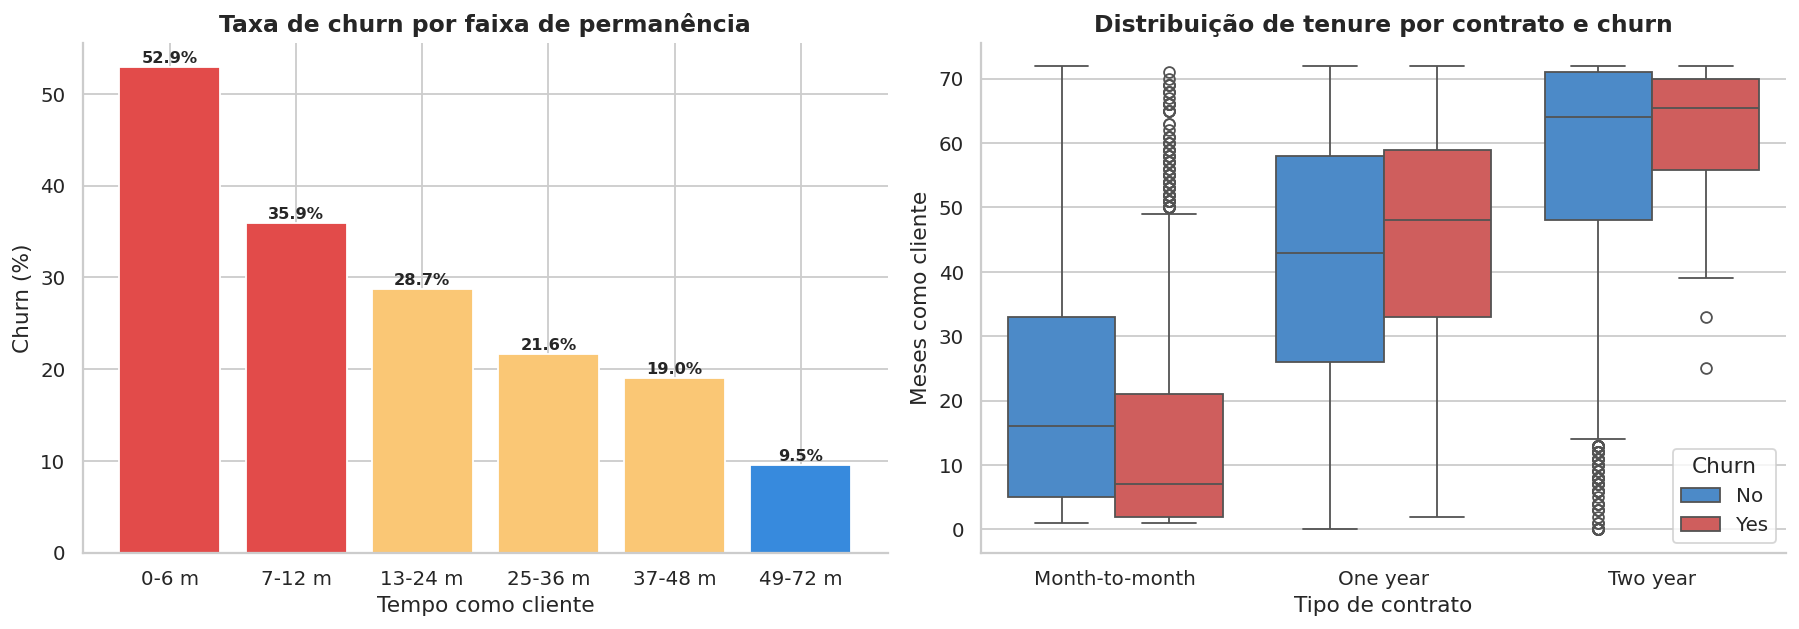

Taxa de churn por faixa de tenure:
tenure_group  churn_rate_pct  total
       0-6 m       52.937205   1481
      7-12 m       35.886525    705
     13-24 m       28.710938   1024
     25-36 m       21.634615    832
     37-48 m       19.028871    762
     49-72 m        9.513176   2239


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate por faixa de tenure
tenure_churn = (
    df.groupby("tenure_group")["churn_binary"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "churn_rate", "count": "total"})
)
tenure_churn["churn_rate_pct"] = tenure_churn["churn_rate"] * 100

ordem = ["0-6 m", "7-12 m", "13-24 m", "25-36 m", "37-48 m", "49-72 m"]
tenure_churn["tenure_group"] = pd.Categorical(
    tenure_churn["tenure_group"], categories=ordem, ordered=True
)
tenure_churn = tenure_churn.sort_values("tenure_group")

colors = ["#E24B4A" if r > 30 else "#FAC775" if r > 15 else "#378ADD"
          for r in tenure_churn["churn_rate_pct"]]

bars = axes[0].bar(tenure_churn["tenure_group"],
                   tenure_churn["churn_rate_pct"],
                   color=colors, edgecolor="white")
axes[0].set_title("Taxa de churn por faixa de permanência")
axes[0].set_xlabel("Tempo como cliente")
axes[0].set_ylabel("Churn (%)")
for bar, val in zip(bars, tenure_churn["churn_rate_pct"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")

# Boxplot: tenure por tipo de contrato e churn
sns.boxplot(data=df, x="contract", y="tenure",
            hue="churn", palette=CHURN_COLORS, ax=axes[1])
axes[1].set_title("Distribuição de tenure por contrato e churn")
axes[1].set_xlabel("Tipo de contrato")
axes[1].set_ylabel("Meses como cliente")
axes[1].legend(title="Churn")

plt.tight_layout()
plt.savefig("../notebooks/fig_06_tenure_risco.png", bbox_inches="tight")
plt.show()

print("Taxa de churn por faixa de tenure:")
print(tenure_churn[["tenure_group", "churn_rate_pct", "total"]].to_string(index=False))


**Insight 6:** O risco de churn cai drasticamente com o tempo. Clientes nos primeiros 6 meses cancelam a uma taxa de ~47% — quase 1 em cada 2. Após 24 meses, essa taxa cai para menos de 15%. Isso define claramente uma "janela crítica de retenção" nos primeiros 12 meses, onde esforços de engajamento têm maior retorno.


---
## 7. Correlação entre variáveis numéricas


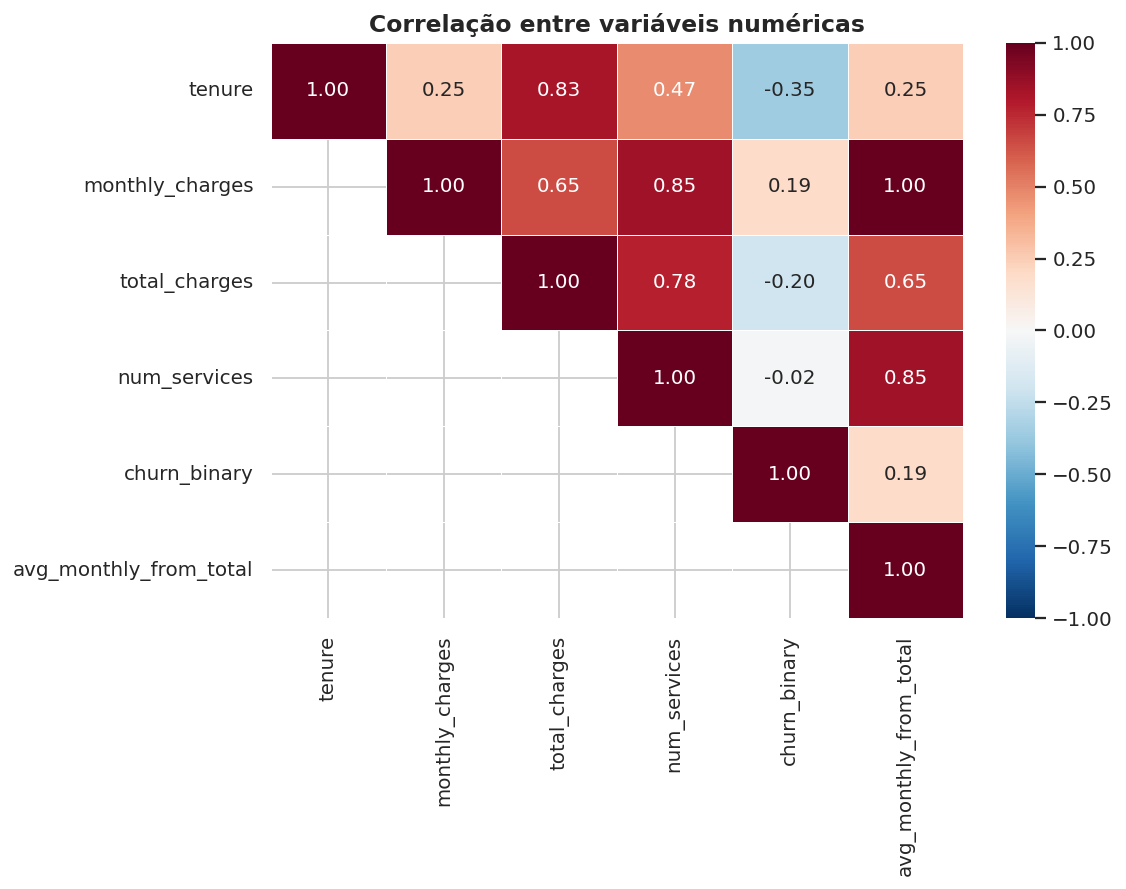

In [25]:
num_cols = ["tenure", "monthly_charges", "total_charges",
            "num_services", "churn_binary", "avg_monthly_from_total"]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = pd.DataFrame(False, index=corr.index, columns=corr.columns)
for i in range(len(mask)):
    for j in range(i):
        mask.iloc[i, j] = True

sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, mask=mask,
            annot_kws={"size": 11})
ax.set_title("Correlação entre variáveis numéricas")
plt.tight_layout()
plt.savefig("../notebooks/fig_07_correlacao.png", bbox_inches="tight")
plt.show()


**Insight 7:** `churn_binary` tem correlação negativa com `tenure` (-0.35) — quanto mais tempo de casa, menor o churn. A correlação positiva com `monthly_charges` (+0.19) confirma que clientes que pagam mais tendem a cancelar mais. `total_charges` tem correlação forte com `tenure` (esperado, é produto de um pelo outro).


---
## 8. Método de pagamento e churn


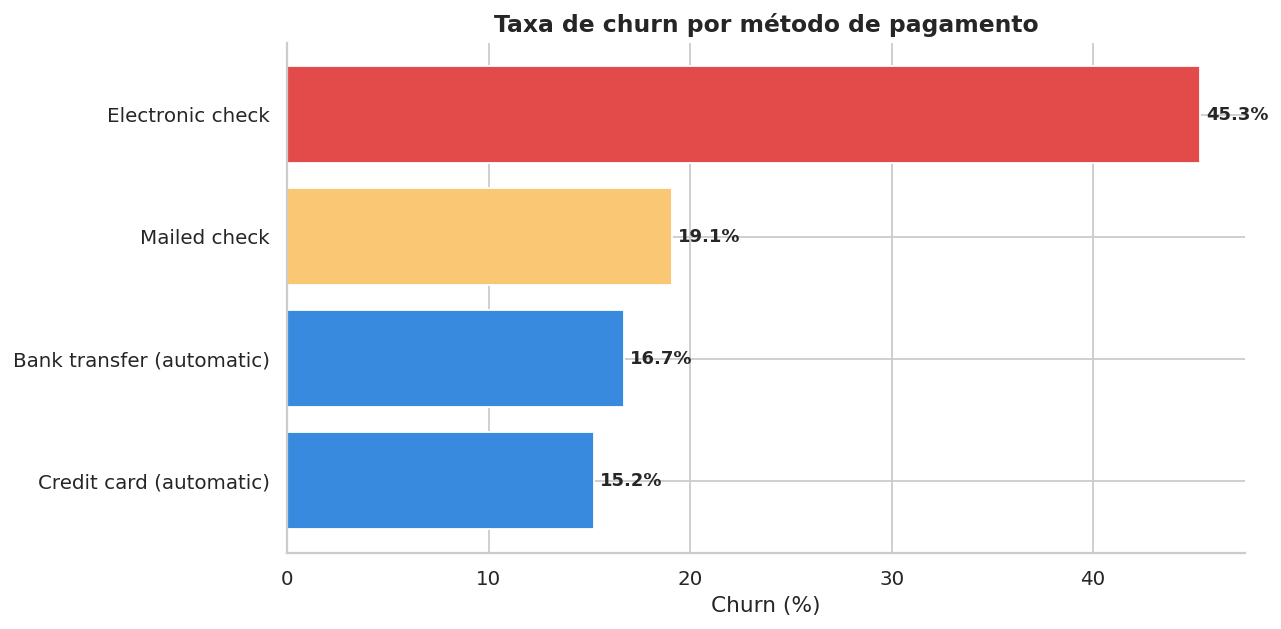

In [26]:
payment_churn = (
    df.groupby("payment_method")["churn_binary"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "churn_rate", "count": "total"})
)
payment_churn["churn_rate_pct"] = payment_churn["churn_rate"] * 100
payment_churn = payment_churn.sort_values("churn_rate_pct", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(payment_churn["payment_method"],
               payment_churn["churn_rate_pct"],
               color=["#378ADD", "#378ADD", "#FAC775", "#E24B4A"],
               edgecolor="white")
ax.set_title("Taxa de churn por método de pagamento")
ax.set_xlabel("Churn (%)")
for bar, val in zip(bars, payment_churn["churn_rate_pct"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("../notebooks/fig_08_pagamento_churn.png", bbox_inches="tight")
plt.show()


**Insight 8:** Clientes que pagam via "Electronic check" têm churn de ~45% — muito acima dos demais métodos (~15-19%). Isso pode indicar um perfil de cliente menos engajado ou com mais atritos no processo de pagamento. Uma ação possível seria incentivar a migração para débito automático ou cartão de crédito.


---
## 9. Conclusões e Recomendações de Negócio

### Resumo dos principais achados

| # | Achado | Impacto |
|---|--------|---------|
| 1 | Clientes nos primeiros 6 meses cancelam a ~47% | Alto |
| 2 | Contrato mensal gera 42% de churn vs 3% em 2 anos | Alto |
| 3 | Electronic check está associado a 45% de churn | Médio |
| 4 | Clientes idosos cancelam 70% mais que não-idosos | Médio |
| 5 | Clientes que cancelam pagam mais por mês ($139K/mês em risco) | Alto |

### Recomendações

1. **Programa de onboarding nos primeiros 90 dias** — a janela crítica é o início do relacionamento. Ações proativas de engajamento nesse período têm maior ROI.

2. **Incentivo para migração de contrato mensal para anual** — desconto ou benefício para upgrade de contrato pode reduzir o churn pela metade nesse segmento.

3. **Campanhas específicas para clientes Fiber optic com contrato mensal** — combinação de maior risco identificada na análise.

4. **Facilitar troca do Electronic check para débito automático** — reduz atrito e está associado a maior retenção.

### Próximos passos
- Etapa 3: Queries SQL respondendo as perguntas de negócio
- Etapa 4: Dashboard Power BI com star schema
- Bônus: Modelo Random Forest para score de propensão ao churn
